In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json
import random
from itertools import combinations

# Dependency:
* DDBC
* DDBC_MSIGDB

# Loading variables

In [2]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY  = f"../output/NONE/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = f"../../Gen_Hypergraph/output/MSIGDB_FULL/"

In [3]:
with open(f"{DGIDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    dgidb_gene_to_index = json.load(f)
with open(f"{MSIGDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    msigdb_gene_to_index = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/gene_to_index_distinct.json", "rb") as f:
    gene_to_index_distinct = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/dgidb_to_msigdb_indices_dict.json", "rb") as f:
    dgidb_to_msigdb_indices_dict = json.load(f)
# with open(f"{OUTPUT_DIRECTORY}/indices.pkl", "rb") as f:
#     indices = pickle.load(f)
# with open(f"{OUTPUT_DIRECTORY}/indices_agg.pkl", "rb") as f:
#     indices_agg = pickle.load(f)

In [4]:
num_distinct_genes = len(gene_to_index_distinct)
num_genes_msigdb = len(msigdb_gene_to_index)
num_additional_rows = num_distinct_genes - num_genes_msigdb

In [5]:
print(num_distinct_genes,num_genes_msigdb,num_additional_rows)

21991 21981 10


In [6]:
# ## Sanity Check
# index_to_gene_distinct = {v: k for k, v in gene_to_index_distinct.items()}
# dgidb_index_to_gene = {v: k for k, v in dgidb_gene_to_index.items()}
# msigdb_index_to_gene = {v: k for k, v in msigdb_gene_to_index.items()}

# for i in range(len(indices_agg)):
#     gene_name = index_to_gene_distinct[indices_agg[i]]
#     p = dgidb_gene_to_index.get(gene_name, None)
#     assert p is not None

# for i in range(len(indices)):
#     gene_name = msigdb_index_to_gene[indices[i]]
#     p = dgidb_gene_to_index.get(gene_name, None)
#     assert p is not None

In [7]:
# load ddm
ddm_both = np.load(f"{OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

In [37]:
ddm_both.mean()

7.04508556755294e-05

In [9]:
ddm_both_cropped = ddm_both[num_additional_rows:, num_additional_rows:]

In [10]:
# load npy arrays for NONE
ddm_msigdb = np.load(f"{NONE_OUTPUT_DIRECTORY}/ddm_[2, 4, 6, 8].npy")

In [38]:
ddm_msigdb.mean()

3.829265883250127e-05

In [11]:
dgidb_indices = [x for x in list(dgidb_to_msigdb_indices_dict.values()) if x is not None]
dgidb_indices_agg = [x + num_additional_rows for x in dgidb_indices]

# New Fig 4

In [15]:
# num_samples = int(1e6)

In [16]:
# # Random Sample
# distance_single = []
# distance_both = []
# for _ in range(num_samples):
#     i, j = random.sample(range(num_genes_msigdb), 2)
#     d_single = ddm_msigdb[i,j]
#     d_both = ddm_both_cropped[i,j]
#     distance_single.append(d_single)
#     distance_both.append(d_both)

In [17]:
# # DGIDB Pairwise Only
# distance_single = []
# distance_both = []
# for i,j in combinations(indices,2):
#     d_single = ddm_msigdb[i,j]
#     d_both = ddm_both_cropped[i,j]
#     distance_single.append(d_single)
#     distance_both.append(d_both)

In [18]:
# plt.scatter(distance_single,distance_both)

In [19]:
# fig, ax = plt.subplots(figsize=(10, 8))

# # --- THE BACKGROUND (Choose Hexbin OR KDE) ---

# # Choice 1: Hexbin (Best if you have millions of points; very fast)
# # 'bins=log' is crucial here so the few dense areas don't wash out the rest
# hb = ax.hexbin(distance_single, distance_both, gridsize=60, cmap='Greys',
#                mincnt=1, bins='log', alpha=0.7)
# cb = fig.colorbar(hb, ax=ax, label='$\log_{10}(N)$ Gene Pairs')

# # Choice 2: Seaborn KDE (Uncomment below if you prefer smooth topographic lines)
# # Note: KDE can be slow to compute if you feed it millions of rows.
# # sns.kdeplot(x=single_layer_bg, y=multi_layer_bg, cmap="Greys", fill=True,
# #             thresh=0.05, levels=10, ax=ax, alpha=0.7)

# # --- THE REFERENCE LINE ---
# # Draw the y=x line to show where points *would* be if nothing changed
# ax.plot([0, 0.035], [0, 0.035], color='black', linestyle='--', linewidth=1.5,
#         alpha=0.8, zorder=3, label='Baseline ($y=x$)')

# # ==========================================
# # 3. FORMATTING FOR PUBLICATION
# # ==========================================
# ax.set_xlabel('Single-Layer Diffusion Distance', fontsize=12, fontweight='bold')
# ax.set_ylabel('Multi-Layer Diffusion Distance', fontsize=12, fontweight='bold')
# ax.set_title('Diffusion Geometry Reshaping: The "Wormhole" Effect', fontsize=14, fontweight='bold')

# # Clean up axes limits based on your actual data
# ax.set_xlim(0, 0.035)
# ax.set_ylim(0, 0.035)

# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, linestyle=':', alpha=0.5)

# plt.tight_layout()
# plt.show()

# diffusion distance comparison

In [25]:
# # average of each row
# ddm_multilayer_avg    = np.asarray(np.mean(ddm_both, axis=1)).ravel()
# ddm_singlelayer_avg = np.asarray(np.mean(ddm_msigdb, axis=1)).ravel()
ddm_multilayer_avg_DGIDB    = np.asarray(np.mean(ddm_both[:,dgidb_indices_agg], axis=1)).ravel()
ddm_singlelayer_avg_DGIDB = np.asarray(np.mean(ddm_msigdb[:,dgidb_indices], axis=1)).ravel()

In [30]:
ddm_multilayer_avg_DGIDB_cropped = ddm_multilayer_avg_DGIDB[num_additional_rows:]

In [34]:
ddm_multilayer_avg_DGIDB_cropped

array([0.00067817, 0.00064803, 0.0007022 , ..., 0.00093186, 0.00086194,
       0.00078788])

In [31]:
ddm_multilayer_avg_DGIDB_cropped.shape

(21981,)

In [35]:
ddm_singlelayer_avg_DGIDB

array([2.78482237e-05, 2.50899081e-05, 3.21692352e-05, ...,
       8.90680733e-05, 3.43880760e-05, 3.51947617e-05])

In [ ]:
# average_diff_dist_DGIDB_MSIGDB_singlelayer = np.asarray([ddm_singlelayer_avg[u] for u in indices])
# average_diff_dist_DGIDB_DGIDB_singlelayer = np.asarray([ddm_singlelayer_avg_DGIDB[u] for u in indices_agg])
# average_diff_dist_MSIGDB_MSIGDB_singlelayer = np.asarray(ddm_singlelayer_avg)

In [ ]:
# average_diff_dist_DGIDB_MSIGDB_multilayer = np.asarray([ddm_multilayer_avg[u] for u in indices_agg])
# average_diff_dist_DGIDB_DGIDB_multilayer = np.asarray([ddm_multilayer_avg_DGIDB[u] for u in indices_agg])
# average_diff_dist_MSIGDB_MSIGDB_multilayer = np.asarray(ddm_multilayer_avg[num_additional_rows:])

In [ ]:
# print(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
# print(len(average_diff_dist_DGIDB_MSIGDB_multilayer))
# print(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
# print(len(average_diff_dist_DGIDB_DGIDB_multilayer))

In [32]:
# setting universal font sizes
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


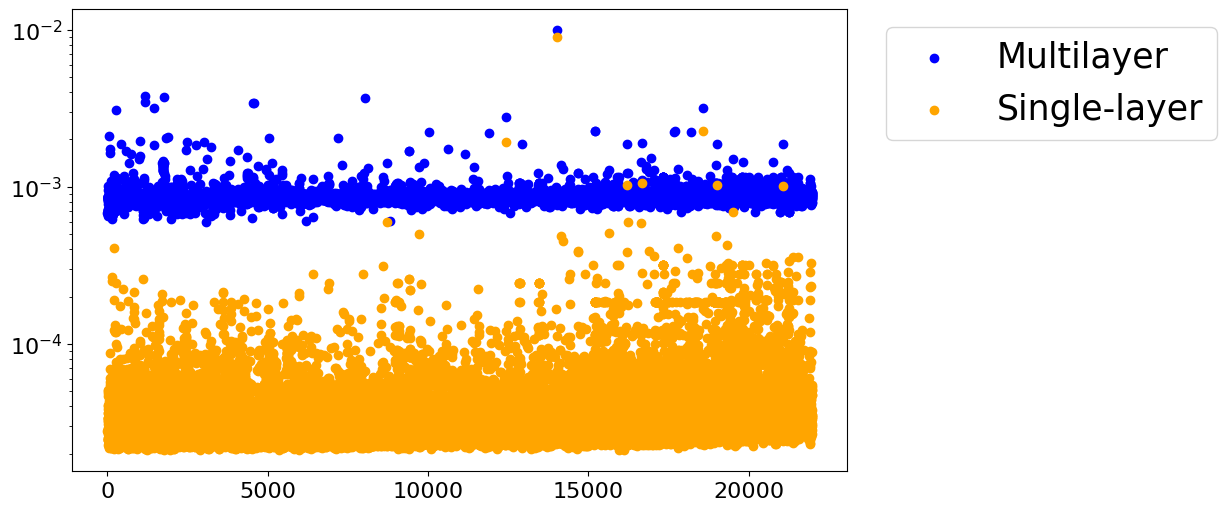

In [33]:
# DGIDB rows comparing to all genes
xaxis = range(len(ddm_multilayer_avg_DGIDB_cropped))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, ddm_multilayer_avg_DGIDB_cropped, label='Multilayer', color='blue')
plt.scatter(xaxis, ddm_singlelayer_avg_DGIDB, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_comp.png", bbox_inches='tight')

In [ ]:
# DGIDB rows comparing to all genes
xaxis = range(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_comp.png", bbox_inches='tight')

In [ ]:
# DGIDB rows comparing to DGIDB genes
xaxis = range(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_DGIDB_comp.png", bbox_inches='tight')

In [ ]:
# all rows comparing to all genes
xaxis = range(len(average_diff_dist_MSIGDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_MSIGDB_MSIGDB_comp.png", bbox_inches='tight')

In [ ]:
# DGIDB rows comparing to all genes - Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    

axes[0].hist(average_diff_dist_DGIDB_MSIGDB_multilayer, bins=100, color='blue')
axes[0].set_title("Multi-layer")
axes[1].hist(average_diff_dist_DGIDB_MSIGDB_singlelayer, bins=100, color='orange')
axes[1].set_title("Single-layer")

fig.supylabel("Frequency", x = 0.05, fontsize = 20)
fig.supxlabel("Average diffusion distance to DGIdb genes", y=0.01, fontsize = 20)  # changed: move shared x-label upward
fig.subplots_adjust(bottom=0.22, wspace=0.08)

plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_histogram.png", bbox_inches='tight')
plt.show()



In [ ]:
# DGIDB rows comparing to all genes - Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

axes[0].hist(average_diff_dist_MSIGDB_MSIGDB_multilayer, bins=100, color='blue')
axes[0].set_title("Multi-layer")

axes[1].hist(average_diff_dist_MSIGDB_MSIGDB_singlelayer, bins=100, color='orange')
axes[1].set_title("Single-layer")

fig.supylabel("Frequency", x = 0.05, fontsize = 20)
fig.supxlabel("Average diffusion distance to DGIdb genes", y=0.01, fontsize = 20)  # changed: move shared x-label upward
fig.subplots_adjust(bottom=0.22, wspace=0.08)

plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_MSIGDB_MSIGDB_histogram.png", bbox_inches='tight')
plt.show()



In [ ]:
diff_dist_stat = {
    "DGIDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.var())},
    "DGIDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_multilayer.var())},
    "DGIDB_DGIDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_singlelayer.var())},
    "DGIDB_DGIDB_multilayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_multilayer.var())},
    "MSIGDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.var())},
    "MSIGDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.var())},
}

In [ ]:
with open(f"../../Graphs/{DISEASE}/diff_dist_stat.json", "w") as f:
    json.dump(diff_dist_stat, f, indent=4)

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.hist([ddm_msigdb_avg,ddm_both_avg_cropped], color=['orange', 'blue'], bins = 1000)
# # plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# # plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot
# plt.legend(['Single-layer', 'Multilayer'], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=17)

In [ ]:
# diff = ddm_both_avg_cropped / ddm_msigdb_avg

# plt.figure(figsize=(10, 6))
# plt.hist(diff, color='orange', bins = 1000)
# plt.axvline(1, color="black", linestyle="--", linewidth=2, label="baseline = 1")
# plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot